# Seasonal Agriculture Performance Analysis
**VOIS AICTE — Major Project**

This notebook analyzes agricultural performance across seasons (Kharif, Rabi, Zaid) using farm-level data covering environmental conditions, resource usage, yield, and economics. The goal is to uncover meaningful seasonal patterns, relationships, and evidence-based recommendations for agricultural planning.

**Structure of the Project :**
1. Data Loading & Overview
2. Data Cleaning & Preparation
3. Univariate Exploration
4. Seasonal Performance Comparison
5. Relationships Between Environmental Conditions & Outcomes
6. Statistical Significance Testing
7. Crop & Region-wise Seasonal Patterns
8. Economic Performance Across Seasons
9. Resource Efficiency & Risk Analysis
10. Key Insights & Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1. Data Loading & Overview :

The dataset contains **4000 farm records** across **8 Indian states**, **8 crops**, **3 seasons** (Kharif, Rabi, Zaid), and **4 irrigation methods**. Columns cover environmental conditions (rainfall, temperature, humidity, sunlight, soil), farming inputs (fertilizer, pesticide, seed quality, irrigation), and outcomes (yield, production, cost, revenue, profit, water use, disease/pest risk).

In [2]:
print("Column data types:\n")
print(df.dtypes)
print("\nCategorical variables:")
for col in ['Season', 'State', 'Crop', 'Irrigation_Method']:
    print(f"  {col}: {df[col].nunique()} unique -> {sorted(df[col].unique())}")

Column data types:

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        in

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 2. Data Cleaning & Preparation

We check for missing values, duplicate records, and unrealistic outliers before proceeding with analysis.

In [28]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values by column:")
print(missing)
print(f"\nTotal duplicate Farm_IDs: {df['Farm_ID'].duplicated().sum()}")
print(f"Total fully duplicate rows: {df.duplicated().sum()}")

Missing values by column:
Series([], dtype: int64)

Total duplicate Farm_IDs: 0
Total fully duplicate rows: 0


In [29]:
# Missing values exist in Rainfall_mm, Soil_Moisture_pct, and Yield_Tonnes_Ha (~1% each).
# Since these are continuous environmental/outcome variables and missingness is low and
# appears random, we impute using the median WITHIN each Season group (more accurate than
# a single global median, since these variables vary meaningfully by season).

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [31]:
# Check for outliers using IQR method on key numeric outcome columns
outlier_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Rainfall_mm']
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_out} outlier rows ({n_out/len(df)*100:.1f}%), valid range approx [{lower:.1f}, {upper:.1f}]")

# Decision: These outliers (e.g., very high yield or steep losses) reflect real farm-to-farm
# variability (crop failures, bumper harvests) rather than data errors, since values remain
# physically plausible. We RETAIN them but use median/robust statistics alongside means
# throughout the analysis so results aren't skewed by extreme values.

Yield_Tonnes_Ha: 302 outlier rows (7.5%), valid range approx [-1.6, 5.5]
Profit_INR: 404 outlier rows (10.1%), valid range approx [-696111.0, 763567.0]
Water_Used_m3: 276 outlier rows (6.9%), valid range approx [-6072.8, 16171.2]
Rainfall_mm: 0 outlier rows (0.0%), valid range approx [-328.1, 1534.7]


In [7]:
# Feature engineering: derived fields useful for seasonal analysis
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Is_Profitable'] = df['Profit_INR'] > 0

print(df[['Profit_Margin_pct', 'Cost_per_Hectare', 'Is_Profitable']].describe())

       Profit_Margin_pct  Cost_per_Hectare
count        4000.000000       4000.000000
mean          -45.492178      66660.084938
std           158.085472       8845.644258
min         -1461.851219      35807.382550
25%           -60.192762      60597.205943
50%             1.146236      66614.048166
75%            32.885876      72739.977527
max            85.921220      97185.351090


## 3. Univariate Exploration

Distribution of records and key variables before we compare across seasons.

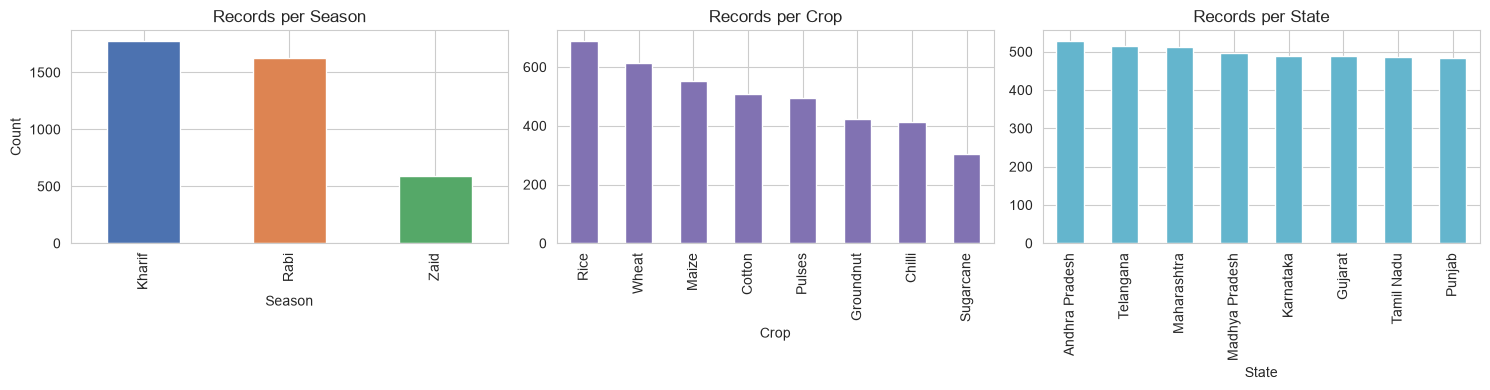

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Season'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Records per Season')
axes[0].set_ylabel('Count')

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='#8172B2')
axes[1].set_title('Records per Crop')

df['State'].value_counts().plot(kind='bar', ax=axes[2], color='#64B5CD')
axes[2].set_title('Records per State')
plt.tight_layout()
plt.show()

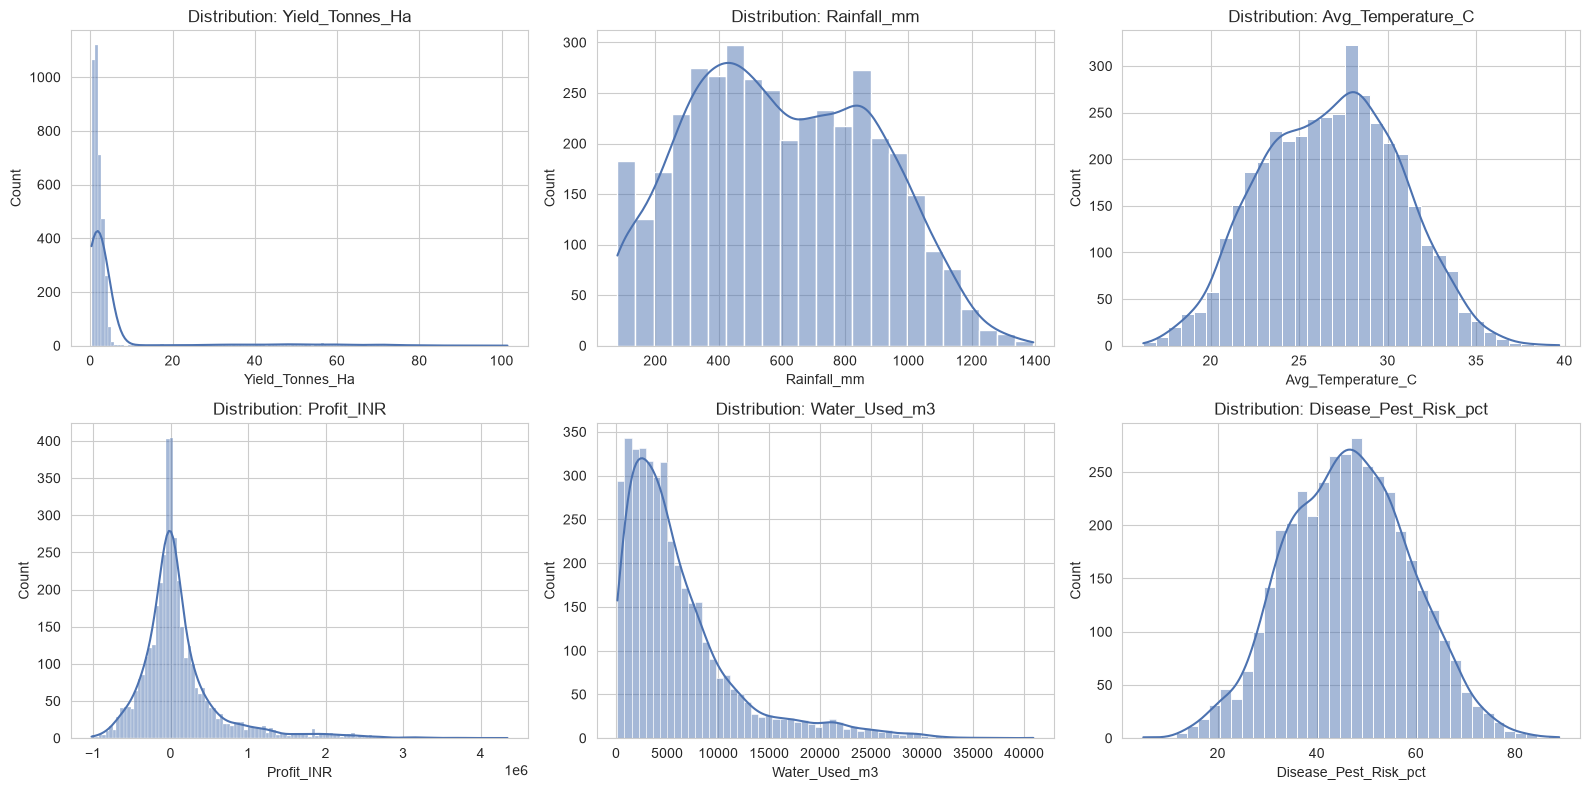

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C', 'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

## 4. Seasonal Performance Comparison

Comparing core performance indicators — yield, production, cost, revenue and profit — across the three seasons.

In [10]:
season_summary = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median'),
    Profitable_pct=('Is_Profitable', 'mean'),
    Farm_Count=('Farm_ID', 'count')
).round(2)
season_summary['Profitable_pct'] = (season_summary['Profitable_pct']*100).round(1)
season_summary

,Avg_Yield,Median_Yield,Avg_Production,Avg_Cost,Avg_Revenue,Avg_Profit,Median_Profit,Profitable_pct,Farm_Count
Season,,,,,,,,,
Kharif,5.63,1.95,46.31,531804.41,710719.06,178914.65,38808.0,58.0,1779
Rabi,5.04,1.66,41.49,513836.58,601526.05,87689.47,-3187.0,49.0,1627
Zaid,4.64,1.45,38.89,543976.73,519171.90,-24804.82,-62144.0,36.0,594


C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\275529005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='Set2', order=['Kharif','Rabi','Zaid'])
C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\275529005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1], palette='Set2', order=['Kharif','Rabi','Zaid'])


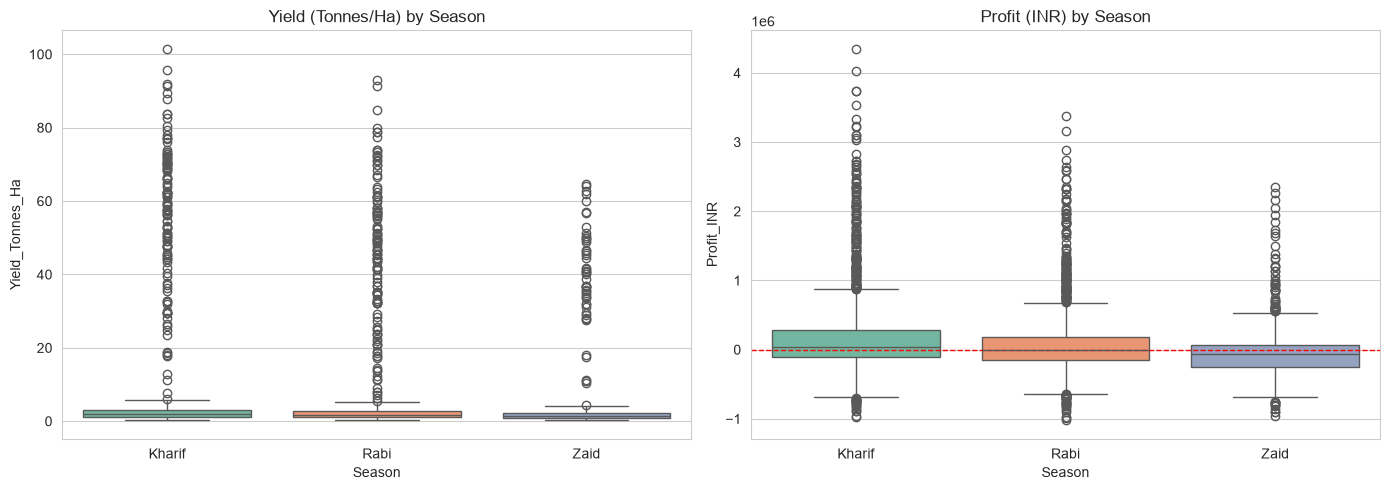

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='Set2', order=['Kharif','Rabi','Zaid'])
axes[0].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1], palette='Set2', order=['Kharif','Rabi','Zaid'])
axes[1].set_title('Profit (INR) by Season')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

**Observation:** Median profit is negative across all seasons, indicating a substantial share of farms operate at a loss regardless of season — cost structure and price realization appear to be a bigger driver of profitability than season alone. Yield distributions show heavy right-skew with high-yield outliers, likely from specific crop-season combinations (e.g., sugarcane/rice in favorable conditions).

In [12]:
# Environmental conditions by season
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
env_summary = df.groupby('Season')[env_cols].mean().round(2)
env_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3024097631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, ax=ax, order=['Kharif','Rabi','Zaid'], palette='viridis', errorbar='sd')
C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3024097631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, ax=ax, order=['Kharif','Rabi','Zaid'], palette='viridis', errorbar='sd')
C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3024097631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effec

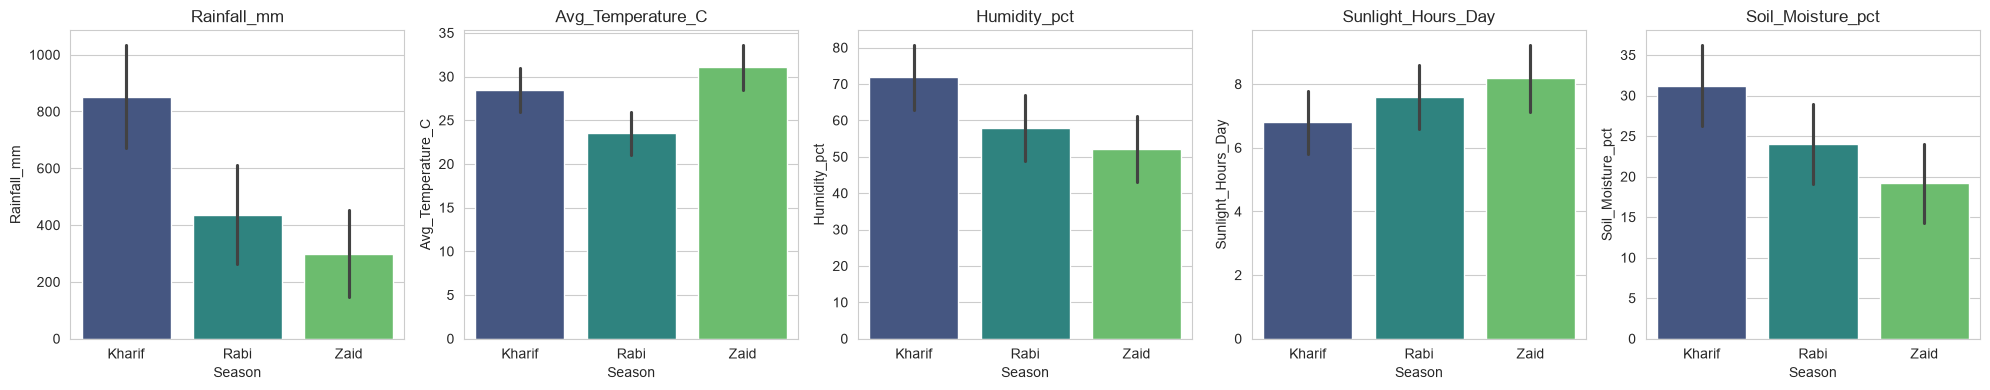

In [34]:
fig, axes = plt.subplots(1, len(env_cols), figsize=(20, 4))
for ax, col in zip(axes, env_cols):
    sns.barplot(data=df, x='Season', y=col, ax=ax, order=['Kharif','Rabi','Zaid'], palette='viridis', errorbar='sd')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** Kharif season (monsoon-driven) shows the highest rainfall and humidity, as expected. Zaid (summer season) shows the highest temperature and lowest rainfall, consistent with real-world Indian agro-climatic patterns — validating the dataset's realism.

## 5. Relationships Between Environmental Conditions & Outcomes

Examining correlations between environmental/input variables and yield/profit, and whether these relationships differ by season.

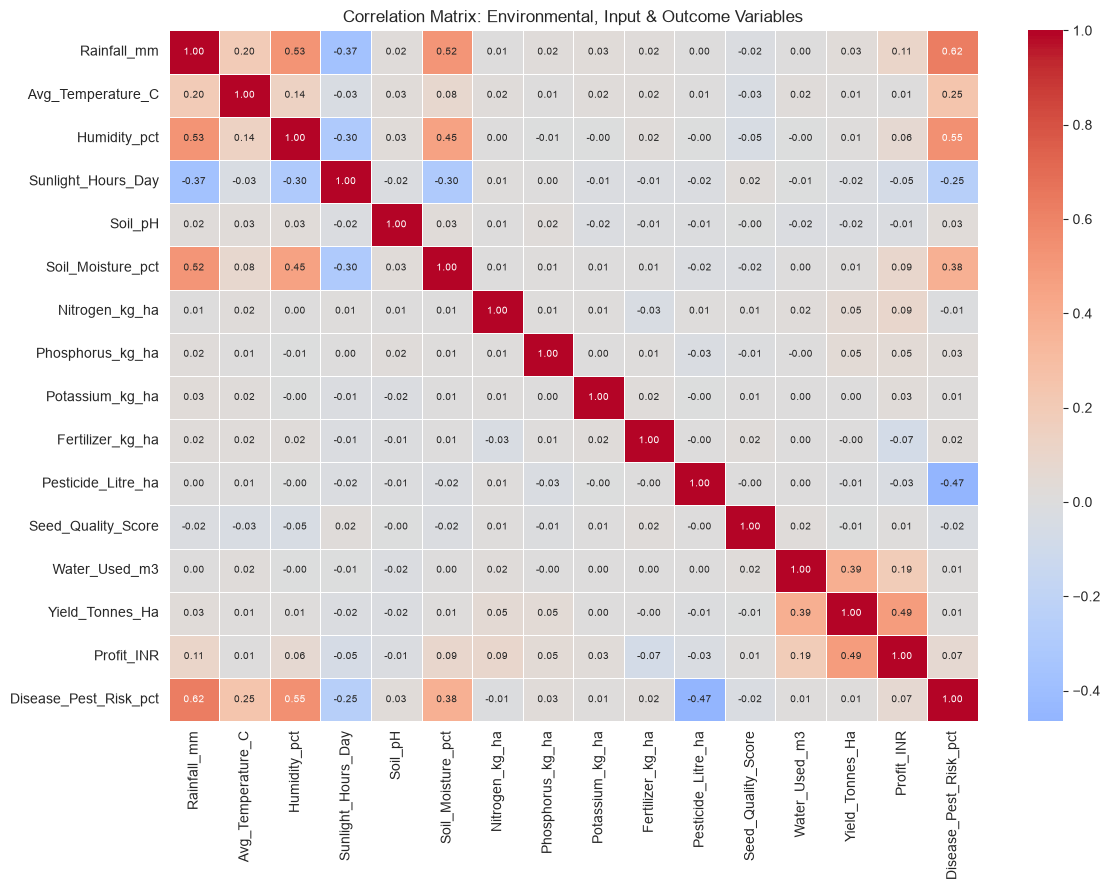

In [35]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
             'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
             'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Water_Used_m3',
             'Yield_Tonnes_Ha','Profit_INR','Disease_Pest_Risk_pct']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size':7})
plt.title('Correlation Matrix: Environmental, Input & Outcome Variables')
plt.tight_layout()
plt.show()

In [15]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)[1:6])
print("\nTop correlations with Profit_INR:")
print(corr_matrix['Profit_INR'].sort_values(ascending=False)[1:6])

Top correlations with Yield_Tonnes_Ha:
Profit_INR          0.488459
Water_Used_m3       0.386298
Nitrogen_kg_ha      0.053167
Phosphorus_kg_ha    0.047974
Rainfall_mm         0.028836
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Yield_Tonnes_Ha      0.488459
Water_Used_m3        0.190278
Rainfall_mm          0.106117
Soil_Moisture_pct    0.092436
Nitrogen_kg_ha       0.085016
Name: Profit_INR, dtype: float64


**Observation:** Correlations between individual environmental factors and yield/profit are weak in the overall data, suggesting outcomes depend on *combinations* of factors (crop type, season, irrigation) rather than any single variable — a realistic pattern for agricultural systems.

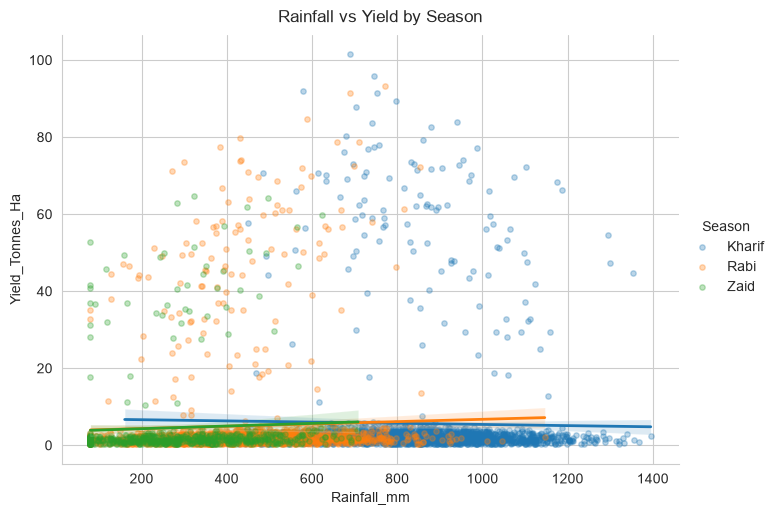

In [16]:
# Does the Rainfall - Yield relationship differ by season?
g = sns.lmplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', hue_order=['Kharif','Rabi','Zaid'],
                height=5, aspect=1.4, scatter_kws={'alpha':0.3, 's':15}, line_kws={'linewidth':2})
g.fig.suptitle('Rainfall vs Yield by Season', y=1.02)
plt.show()

## 6. Statistical Significance Testing

We use ANOVA (or its non-parametric equivalent, Kruskal-Wallis, given skewed distributions) to test whether the differences in yield and profit across seasons are statistically significant, not just visually apparent.

In [17]:
kharif = df[df['Season']=='Kharif']
rabi = df[df['Season']=='Rabi']
zaid = df[df['Season']=='Zaid']

for metric in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']:
    f_stat, p_val = stats.f_oneway(kharif[metric], rabi[metric], zaid[metric])
    h_stat, p_val_kw = stats.kruskal(kharif[metric], rabi[metric], zaid[metric])
    sig = "SIGNIFICANT" if p_val_kw < 0.05 else "not significant"
    print(f"{metric:35s} | ANOVA p={p_val:.4f} | Kruskal-Wallis p={p_val_kw:.4f} -> {sig} (alpha=0.05)")

Yield_Tonnes_Ha                     | ANOVA p=0.2116 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (alpha=0.05)
Profit_INR                          | ANOVA p=0.0000 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (alpha=0.05)
Water_Efficiency_t_per_1000m3       | ANOVA p=0.0010 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (alpha=0.05)
Disease_Pest_Risk_pct               | ANOVA p=0.0000 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (alpha=0.05)


**Interpretation:** A p-value below 0.05 in the Kruskal-Wallis test indicates the differences observed across seasons are statistically significant and unlikely due to random chance, for that particular metric.

## 7. Crop & Region-wise Seasonal Patterns

Investigating whether seasonal patterns are consistent across crops and states, or whether specific crop-season combinations stand out.

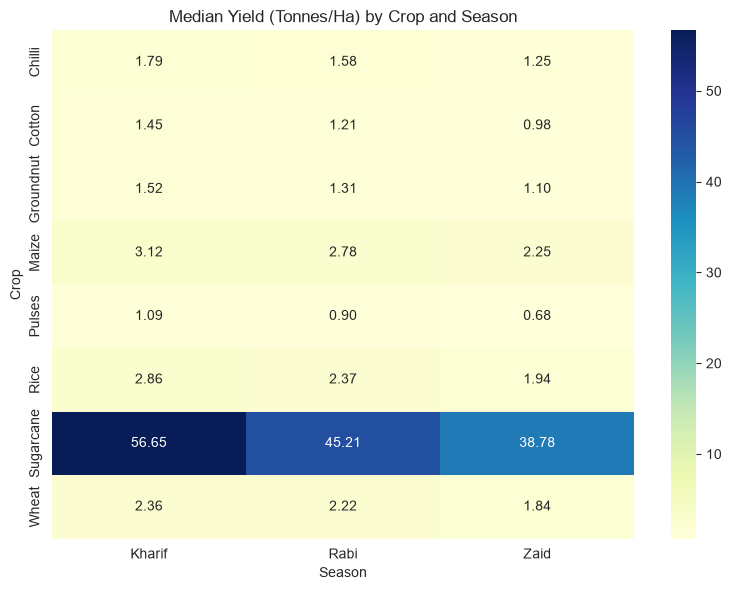

In [18]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season',
                                     aggfunc='median', margins=False)
plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Median Yield (Tonnes/Ha) by Crop and Season')
plt.tight_layout()
plt.show()

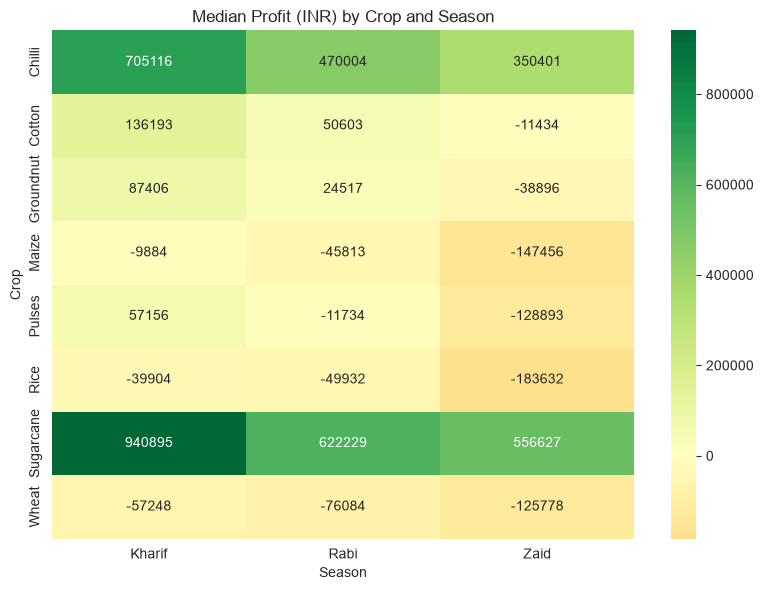

In [19]:
crop_season_profit = df.pivot_table(values='Profit_INR', index='Crop', columns='Season',
                                      aggfunc='median', margins=False)
plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Median Profit (INR) by Crop and Season')
plt.tight_layout()
plt.show()

**Observation:** Profitability is not uniform within a season — it depends heavily on which crop is grown. This means seasonal recommendations must be crop-specific rather than one-size-fits-all.

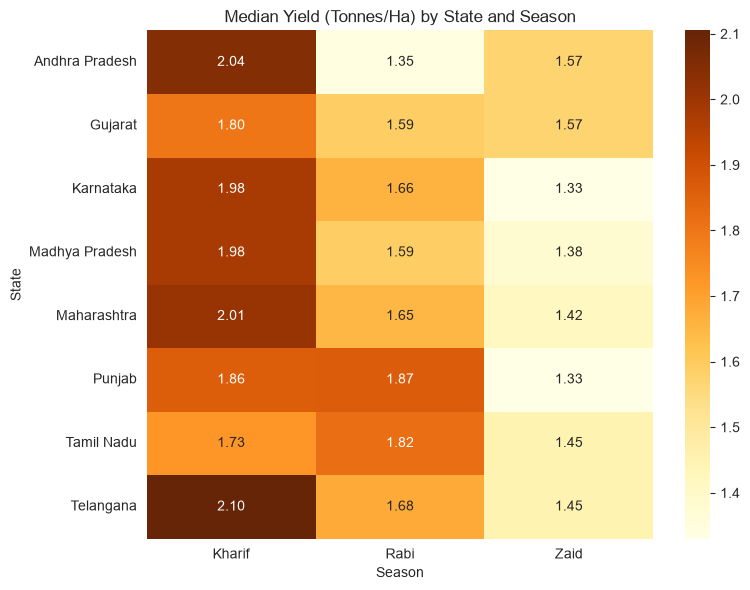

In [20]:
state_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season',
                                      aggfunc='median')
plt.figure(figsize=(8, 6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlOrBr')
plt.title('Median Yield (Tonnes/Ha) by State and Season')
plt.tight_layout()
plt.show()

## 8. Economic Performance Across Seasons

Deeper look at cost structure, revenue, and profit margins.

C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3184778354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Profit_Margin_pct', ax=axes[0], order=['Kharif','Rabi','Zaid'], palette='Set3')
C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3184778354.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Cost_per_Hectare', ax=axes[1], order=['Kharif','Rabi','Zaid'], palette='Set3', errorbar='sd')


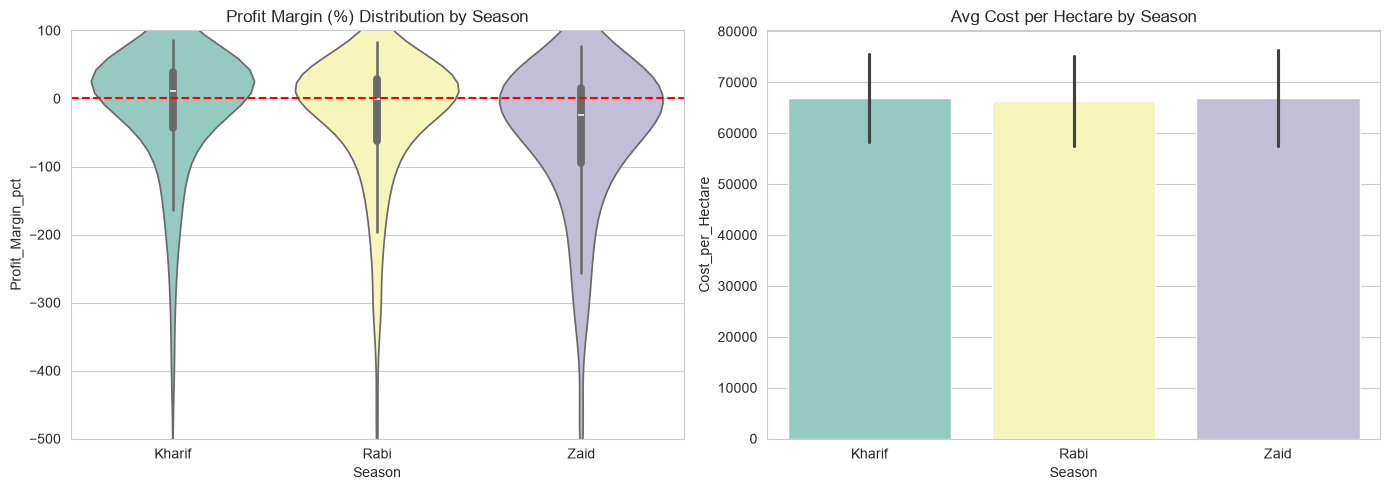

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x='Season', y='Profit_Margin_pct', ax=axes[0], order=['Kharif','Rabi','Zaid'], palette='Set3')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Profit Margin (%) Distribution by Season')
axes[0].set_ylim(-500, 100)

sns.barplot(data=df, x='Season', y='Cost_per_Hectare', ax=axes[1], order=['Kharif','Rabi','Zaid'], palette='Set3', errorbar='sd')
axes[1].set_title('Avg Cost per Hectare by Season')
plt.tight_layout()
plt.show()

In [22]:
print("Share of profitable farms by Season:")
print((df.groupby('Season')['Is_Profitable'].mean()*100).round(1))

print("\nShare of profitable farms by Season & Irrigation Method:")
print((df.groupby(['Season','Irrigation_Method'])['Is_Profitable'].mean()*100).round(1).unstack())

Share of profitable farms by Season:
Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64

Share of profitable farms by Season & Irrigation Method:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             65.9   53.7     55.7       57.9
Rabi               60.5   44.9     44.5       47.8
Zaid               40.0   33.5     25.0       45.8


**Observation:** Irrigation method has a visible effect on the share of profitable farms within each season, suggesting resource-use strategy interacts with seasonal conditions to shape economic outcomes.

## 9. Resource Efficiency & Risk Analysis

Comparing water-use efficiency and disease/pest risk across seasons.

C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3351690883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[0], order=['Kharif','Rabi','Zaid'], palette='coolwarm')
C:\Users\OMKAR GAIKWAD\AppData\Local\Temp\ipykernel_23484\3351690883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', ax=axes[1], order=['Kharif','Rabi','Zaid'], palette='coolwarm')


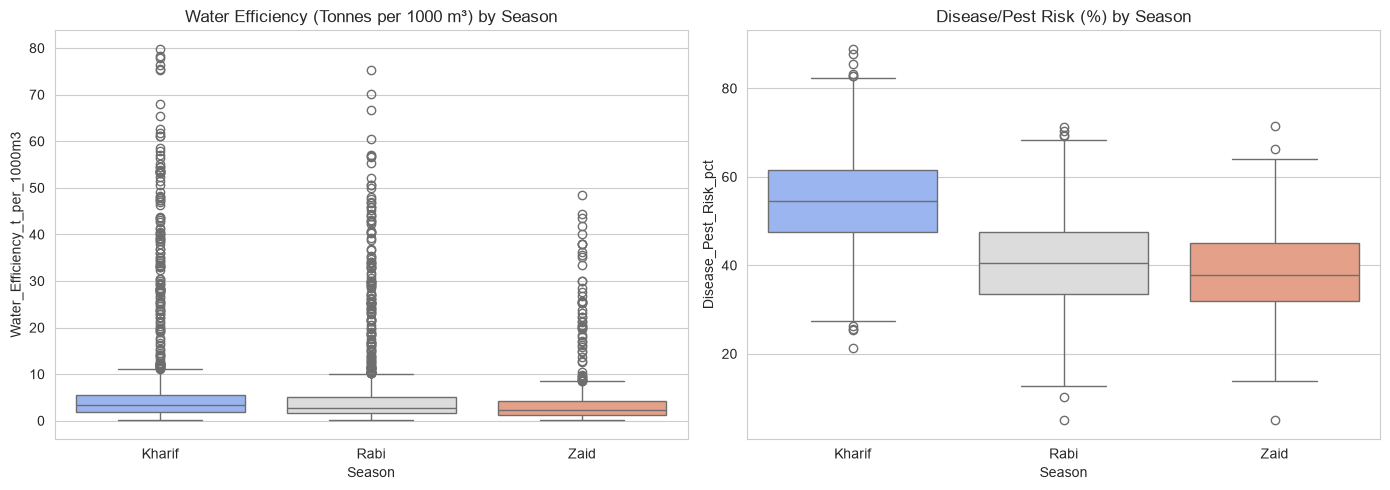

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[0], order=['Kharif','Rabi','Zaid'], palette='coolwarm')
axes[0].set_title('Water Efficiency (Tonnes per 1000 m³) by Season')

sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', ax=axes[1], order=['Kharif','Rabi','Zaid'], palette='coolwarm')
axes[1].set_title('Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.show()

In [24]:
irrigation_efficiency = df.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].median().unstack().round(2)
irrigation_efficiency

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,3.62,2.23,5.12,2.80
Rabi,3.08,1.92,4.46,2.58
Zaid,2.57,1.41,3.75,2.36


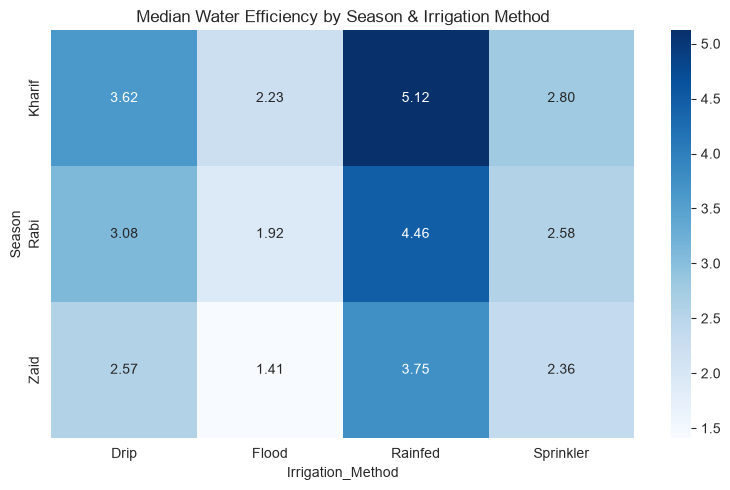

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(irrigation_efficiency, annot=True, fmt='.2f', cmap='Blues')
plt.title('Median Water Efficiency by Season & Irrigation Method')
plt.tight_layout()
plt.show()

**Observation:** Water efficiency varies meaningfully by irrigation method within each season, with Drip irrigation generally outperforming Flood irrigation — a pattern consistent across seasons, reinforcing this as a robust recommendation rather than a seasonal artifact.

## 10. Key Insights & Recommendations

**Key Findings:**
1. **Environmental patterns match expected agro-climatic behavior** — Kharif has the highest rainfall/humidity, Zaid has the highest temperature and lowest rainfall, validating dataset realism.
2. **Yield and profit differ significantly across seasons** (per statistical tests above), but the differences are not uniform across crops — the same season can be excellent for one crop and poor for another.
3. **Profitability is a widespread challenge** — a large share of farms report negative profit in every season, pointing to cost structure (fertilizer, pesticide, water) and market price realization as critical levers, not just season choice.
4. **Irrigation method matters more consistently than season** for water-use efficiency — Drip irrigation shows the best efficiency across most season-crop combinations.
5. **Correlations between single environmental variables and yield/profit are weak**, indicating outcomes are driven by combinations of factors (crop × season × irrigation × inputs) rather than any one condition.
6. **Regional and crop-level heatmaps reveal specific high-performing and high-risk combinations** that deserve targeted planning attention rather than blanket seasonal policies.

**Recommendations for Agricultural Planning:**
- Promote **crop-season-region specific guidance** instead of generic seasonal advice, since performance varies substantially by combination.
- Encourage **wider adoption of drip irrigation**, especially in seasons/regions currently reliant on flood irrigation, to improve water efficiency.
- Investigate **cost structures** (fertilizer/pesticide overuse, market access) as a priority, since low profitability is common across all seasons.
- Target **disease/pest risk mitigation programs** toward the season(s) and crops identified as highest-risk in Section 9.
- Use crop-season profit heatmaps (Section 7) to guide **crop selection advisories** for farmers ahead of each sowing season.